# Time Series Features with pandas

<hr style="clear:both">

This notebook is part of a series of exercises for the CIVIL-226 Introduction to Machine Learning for Engineers course at EPFL. Copyright (c) 2021-2026 [VITA](https://www.epfl.ch/labs/vita/) lab at EPFL  
Use of this source code is governed by an MIT-style license that can be found in the LICENSE file or at https://www.opensource.org/licenses/MIT

<hr style="clear:both">

In civil engineering, you will frequently encounter time series data: continuous measurements taken over time. Examples include structural health monitoring (vibrations on a bridge), traffic flow sensors, or environmental data (temperature, wind speed).

Before feeding this raw sequence data into a traditional Machine Learning model, it is often necessary to extract **statistical features**. This process summarizes the time series into discrete variables (like the local maximum, mean, or variance) that algorithms can easily process.

In this tutorial, we will use pandas to compute statistical features from time series data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Setting up a Time Series DataFrame

Let's generate some synthetic sensor data representing hourly strain measurements on a structural component over one month.

In [3]:
np.random.seed(42)

# Create an hourly datetime index for 30 days
time_index = pd.date_range(start="2026-04-01", periods=30*24, freq="h")

# Generate a synthetic signal: a daily cycle + some random sensor noise
daily_cycle = np.sin(np.linspace(0, 30 * 2 * np.pi, len(time_index)))
noise = np.random.normal(0, 0.2, len(time_index))
sensor_data = 10 + 2 * daily_cycle + noise

# Build the DataFrame
df = pd.DataFrame({"strain_mu": sensor_data}, index=time_index)

df.head()

,strain_mu
2026-04-01 00:00:00,10.099343
2026-04-01 01:00:00,10.490689
2026-04-01 02:00:00,11.130799
2026-04-01 03:00:00,11.720364
2026-04-01 04:00:00,11.686675


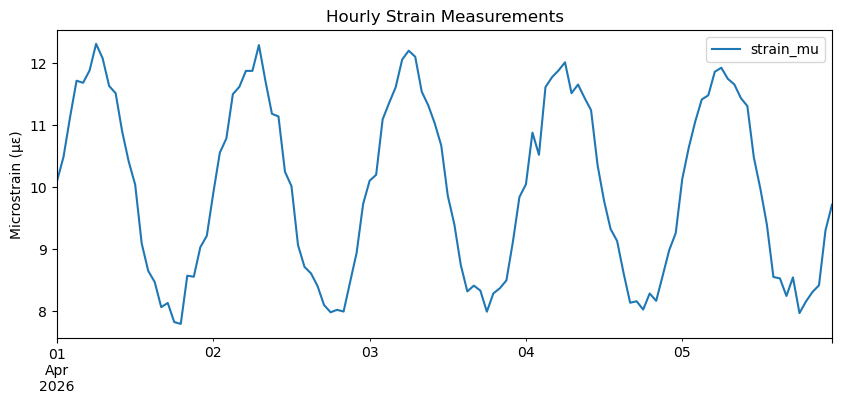

In [4]:
# Let's visualize the first 5 days of our data
df.iloc[:5*24].plot(figsize=(10, 4), title="Hourly Strain Measurements", ylabel="Microstrain (µε)")
plt.show()

## 2. Global Statistical Features

The simplest way to summarize a time series is to compute global statistics over the entire dataset. Pandas provides built-in methods for this, including some useful ones for engineering like skewness and kurtosis (which can indicate anomalies or impacts).

In [5]:
print(f"Mean:     {df['strain_mu'].mean():.2f}")
print(f"Variance: {df['strain_mu'].var():.2f}")
print(f"Max:      {df['strain_mu'].max():.2f}")
print(f"Min:      {df['strain_mu'].min():.2f}")
print(f"Skewness: {df['strain_mu'].skew():.2f}") # Measures asymmetry
print(f"Kurtosis: {df['strain_mu'].kurt():.2f}") # Measures "tailedness" (heavy tails)

Mean:     10.00
Variance: 2.03
Max:      12.46
Min:      7.61
Skewness: 0.01
Kurtosis: -1.47


## 3. Rolling Window Features

In machine learning, we rarely use global statistics. Instead, we want to know the local behavior of the time series at a given moment. 

We use `.rolling()` to create a sliding window of a specified size, and then apply a statistical function. This is standard practice for feature engineering.

In [ ]:
#you can adjust the windows size to see the effect
window_size = 24 #(try also 12, 6 , 3)


# Compute a 24-hour rolling moving average
df["rolling_mean_24h"] = df["strain_mu"].rolling(window=window_size).mean()

# Compute a 24-hour rolling standard deviation (useful for detecting periods of high volatility)
df["rolling_std_24h"] = df["strain_mu"].rolling(window=window_size).std()

df.head(30)

df[["strain_mu", "rolling_mean_24h"]].iloc[:5*24].plot(figsize=(10, 4))

,strain_mu,rolling_mean_24h,rolling_std_24h
2026-04-01 00:00:00,10.099343,NaN,NaN
2026-04-01 01:00:00,10.490689,NaN,NaN
2026-04-01 02:00:00,11.130799,NaN,NaN
2026-04-01 03:00:00,11.720364,NaN,NaN
2026-04-01 04:00:00,11.686675,NaN,NaN
2026-04-01 05:00:00,11.885963,NaN,NaN
2026-04-01 06:00:00,12.315838,NaN,NaN
2026-04-01 07:00:00,12.084013,NaN,NaN
2026-04-01 08:00:00,11.635236,NaN,NaN
2026-04-01 09:00:00,11.518084,NaN,NaN


> Note: The first 23 rows of the rolling columns are `NaN` because a full 24-hour window hasn't accumulated yet. You can use `.dropna()` to remove these before training your ML model.

<Axes: >

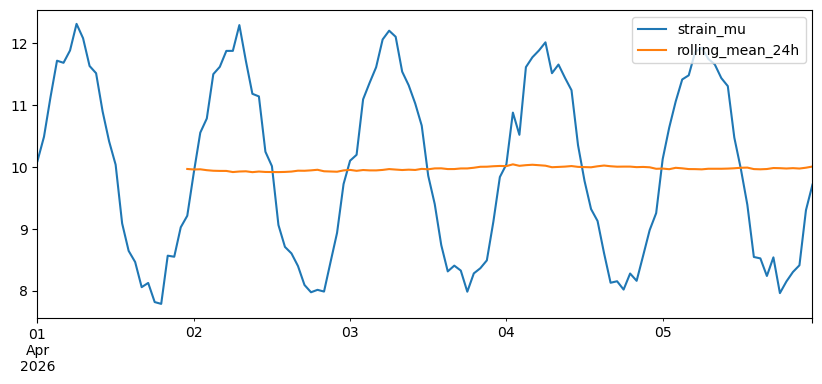

## 4. Resampling (Downsampling)

Sometimes your sensor records data at 100 Hz, but you only need minute-by-minute or daily features. `.resample()` acts like a `groupby` operation for datetime indices.

You provide a frequency string (e.g., `'D'` for Day, `'W'` for Week, `'15min'` for 15 minutes), followed by an aggregation function.

In [ ]:
# Resample hourly data to daily data, taking the maximum strain observed each day
daily_max = df["strain_mu"].resample("D").max()
daily_max.head()

You can also compute multiple features simultaneously using `.agg()`:

In [ ]:
daily_features = df["strain_mu"].resample("D").agg(["mean", "std", "min", "max"])
daily_features.head()

## 5. Differences and Rate of Change

To make a time series stationary (a common requirement for ML forecasting), or to simply use the "rate of change" as a feature, you can use `.diff()` or `.pct_change()`.

In [ ]:
# Calculate the difference between the current hour and the previous hour (t - t_minus_1)
df["strain_diff"] = df["strain_mu"].diff(periods=1)

df[["strain_mu", "strain_diff"]].head()

## Summary

You now have a dataset enriched with statistical features extracted from the time domain. These columns (`rolling_mean`, `rolling_std`, `strain_diff`) can now be passed as input features ($X$) into a regression or classification algorithm.

### Additional time series resources
- Pandas Time Series Documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html
- Offset Aliases (Frequency strings for resampling): https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases